# Sharpness of the best BoTorch loss found across a wandb project

Given a `wandb` project (many BO runs of `experiments/botorch_optimize.py`), this notebook:

1. Scans every run's logged history to find the **global best `loss`** across all runs,
   together with the design point `x` and the GP ARD **lengthscale** the optimizer
   was using at the iteration that produced it.
2. Reconstructs the *exact* training data (`X`, `Y`, `Y_var`) the GP was fit on right
   before proposing that candidate, by pulling the periodic `checkpoint` wandb
   Artifacts that `botorch_optimize.py` uploads (`botorch_state.json`).
3. Refits the same `SingleTaskGP` (matching `propose_next()` in `botorch_optimize.py`)
   on that training data, as a **cheap surrogate** for the true (expensive VMEC +
   alpha-particle-tracing) objective.
4. Uses **central finite differences on the GP posterior mean, along random
   lengthscale-weighted directions**, to estimate the gradient and curvature
   around the best `x`. Each random direction perturbs every DOF at once, with
   `h_j = PERTURB_SCALE * lengthscale_j * z_j` per dimension (`z_j ~ N(0,1)`),
   so the probe distance in each dimension matches the scale the GP itself
   considers the function to vary over, while the combined direction avoids
   the degeneracies of probing one axis at a time (e.g. a DOF sitting exactly
   on a bound).
5. Reports and plots whether the optimum looks like a **sharp, narrow spike**
   (large curvature, loss shoots up within a fraction of a lengthscale) or a
   **broad, well-conditioned basin** (small curvature relative to the overall
   loss range).

We deliberately avoid re-running VMEC/tracing (expensive, and not needed to answer
"is the *believed* landscape sharp around the best point?") — the GP surrogate
already encodes exactly what the optimizer believed about local smoothness at that
iteration, since its lengthscale is refit fresh every iteration in
`propose_next()`.


In [21]:
import json
import os
import re
import tempfile

import numpy as np
import pandas as pd
import torch
import wandb
import yaml
import matplotlib.pyplot as plt

from botorch.fit import fit_gpytorch_mll
from botorch.models import SingleTaskGP
from botorch.models.transforms.input import Normalize
from botorch.models.transforms.outcome import Standardize
from botorch.models.utils.gpytorch_modules import get_covar_module_with_dim_scaled_prior
from gpytorch.mlls import ExactMarginalLogLikelihood

torch.set_default_dtype(torch.double)


## Parameters

In [22]:
# --- wandb project to analyze ---
PROJECT = "garabedian_linear_cei_pressure"
ENTITY = "sp2582-cornell-university"

# Local config used for this project's runs (bounds, kernel type). Every run in
# botorch_optimize.py also logs its own `cfg` to wandb (`run.config`), but we use
# the local yaml directly per the project convention.
CONFIG_PATH = "../configs/garabedian_linear_pressure.yaml"

# Finite-difference step, per dimension j, for each random direction draw:
# h_j = PERTURB_SCALE * lengthscale_j * z_j  (z_j standard normal) -- a
# fraction of each dimension's GP ARD lengthscale, combined randomly across
# all dimensions at once.
PERTURB_SCALE = 0.05

# Number of random lengthscale-weighted directions to probe around x_best.
N_RANDOM_DIRECTIONS = 200
RANDOM_SEED = 0

# Use the lengthscale wandb logged at the best iteration (True) instead of the
# lengthscale from the GP we refit here (False, default). The refit GP is what
# we actually differentiate, so its own lengthscale is the self-consistent
# choice; the logged one is kept around as a sanity-check comparison either way.
USE_LOGGED_LENGTHSCALE = False

# How many of the sharpest random directions to show in the 1D spike/basin
# profile plots.
N_PROFILE_DIRECTIONS = 3


In [23]:
with open(CONFIG_PATH) as f:
    cfg = yaml.safe_load(f)

if cfg.get("wandb_project") != PROJECT:
    print(f"WARNING: CONFIG_PATH's wandb_project ('{cfg.get('wandb_project')}') "
          f"does not match PROJECT ('{PROJECT}'). Double check CONFIG_PATH.")

print(f"use_gp_constraints={cfg['use_gp_constraints']}, kernel={cfg['kernel']!r}, x_min={cfg['x_min']}")


use_gp_constraints=True, kernel='matern', x_min=0.0


## Step 1 — find the global best `loss` across every run in the project

For each run we take the logged row with the lowest `loss` among rows where
neither `vmec_failed` nor `tracing_failed` is set, then compare the per-run
minima to find the overall best.

In [24]:
def fetch_run_dataframe(run):
    """Full (unsampled) logged history for a run as a DataFrame, or None."""
    rows = list(run.scan_history())
    if not rows:
        return None
    df = pd.DataFrame(rows)
    if "iteration" not in df.columns or "loss" not in df.columns:
        return None
    df = df.dropna(subset=["iteration", "loss"]).copy()
    if df.empty:
        return None
    df["iteration"] = df["iteration"].astype(int)
    for flag in ("vmec_failed", "tracing_failed"):
        if flag not in df.columns:
            df[flag] = 0.0
        df[flag] = df[flag].fillna(0.0)
    return df.sort_values("iteration").reset_index(drop=True)


api = wandb.Api()
path = f"{ENTITY}/{PROJECT}" if ENTITY else PROJECT
runs = list(api.runs(path))
print(f"Found {len(runs)} run(s) in '{path}'")

best_run, best_row = None, None
per_run_best = []
for run in runs:
    df = fetch_run_dataframe(run)
    if df is None:
        continue
    valid = df[(df["vmec_failed"] == 0) & (df["tracing_failed"] == 0) & np.isfinite(df["loss"])]
    if valid.empty:
        continue
    row = valid.loc[valid["loss"].idxmin()]
    per_run_best.append((run.name, int(row["iteration"]), float(row["loss"])))
    if best_row is None or row["loss"] < best_row["loss"]:
        best_run, best_row = run, row

if best_run is None:
    raise RuntimeError(f"No run in '{path}' has any valid logged 'loss'.")

i_star = int(best_row["iteration"])
print(f"\nGlobal best: run='{best_run.name}', iteration={i_star}, loss={best_row['loss']:.6e}\n")

per_run_best_df = pd.DataFrame(per_run_best, columns=["run", "best_iteration", "best_loss"])
per_run_best_df = per_run_best_df.sort_values("best_loss").reset_index(drop=True)
per_run_best_df.head(20)


Found 10 run(s) in 'sp2582-cornell-university/garabedian_linear_cei_pressure'

Global best: run='fanciful-sweep-10', iteration=402, loss=-7.397431e-01



,run,best_iteration,best_loss
0,fanciful-sweep-10,402,-0.739743
1,silvery-sweep-9,711,0.631224
2,comic-sweep-12,391,0.730403
3,snowy-sweep-13,778,0.840491
4,morning-sweep-10,251,1.466213
5,fanciful-sweep-5,704,2.417290
6,swift-sweep-1,690,3.016745
7,frosty-sweep-3,467,3.540856
8,ethereal-sweep-4,471,4.465133


In [25]:
ls_cols = sorted(
    (c for c in best_row.index if c.startswith("gp/lengthscale_")),
    key=lambda c: int(c.split("_")[-1]),
)
lengthscale_logged = best_row[ls_cols].to_numpy(dtype=float)
print(f"Logged GP lengthscale at iteration {i_star} ({len(lengthscale_logged)} dims):")
print(np.array2string(lengthscale_logged, precision=4))


Logged GP lengthscale at iteration 402 (23 dims):
[2.3278 1.431  2.4762 1.0591 1.003  0.588  0.1023 0.1244 0.2144 0.2859
 0.2419 0.169  0.3403 4.5226 1.15   0.4409 0.4015 0.5402 6.5284 2.7428
 1.6746 1.0132 2.2199]


## Step 2 — reconstruct the exact GP training data for that iteration

`botorch_optimize.py` uploads a `checkpoint` wandb Artifact (`state_{n:06d}`) every
`save_frequency` iterations, containing the full `botorch_state.json` with the
cumulative `X`/`Y`/`Y_var` arrays used by the optimizer, plus a dense `results`
list (one entry per *attempted* trial, success or failure, in order).

**Note:** wandb's logged `iteration` is *not* a direct index into `X`/`Y`.
`botorch_optimize.py` logs one wandb row per trial regardless of outcome, but
when `cfg["use_gp_constraints"]` is `True`, only successful trials are ever
appended to `X_t`/`Y_t` (failures go only to the constraint-model arrays). So
`X`/`Y` are "compacted" (successes only) while `iteration` is dense — once any
earlier trial in the run has failed, `X[i_star]` silently points at the wrong
row. We use the dense `results` list to recover the correct compacted
position for `i_star`, then slice up to (not including) that position to get
exactly the training set the GP was fit on right before proposing the best `x`
(matching `propose_next()`'s `X_t`/`Y_t` at that point).

In [26]:
def load_state_from_checkpoint(run, min_len):
    """Return (state_dict, checkpoint_n) for the smallest checkpoint whose
    dense `results` list covers at least `min_len` trials, or the largest
    available checkpoint as a best-effort fallback (with a warning) if none
    is big enough."""
    candidates = []
    for art in run.logged_artifacts():
        if art.type != "checkpoint":
            continue
        m = re.match(r"state_(\d+)", art.name)
        if not m:
            continue
        candidates.append((int(m.group(1)), art))
    candidates.sort(key=lambda t: t[0])
    if not candidates:
        return None, None

    for n, art in candidates:
        if n >= min_len:
            with tempfile.TemporaryDirectory() as d:
                local_dir = art.download(root=d)
                state_path = os.path.join(local_dir, "botorch_state.json")
                with open(state_path) as f:
                    state = json.load(f)
            if len(state["results"]) >= min_len:
                return state, n

    n, art = candidates[-1]
    print(f"WARNING: no checkpoint covers trial {min_len - 1}; falling back to the "
          f"largest available checkpoint (state_{n:06d}). Training set may be incomplete.")
    with tempfile.TemporaryDirectory() as d:
        local_dir = art.download(root=d)
        state_path = os.path.join(local_dir, "botorch_state.json")
        with open(state_path) as f:
            state = json.load(f)
    return state, n


def position_in_checkpoint(results, iteration, use_gp_constraints):
    """Map a dense wandb/trial 'iteration' index to its (possibly compacted)
    position in the checkpoint's X/Y arrays.

    botorch_optimize.py logs one wandb row per trial (success or failure),
    but when cfg["use_gp_constraints"] is True, only *successful* trials are
    ever appended to X_t/Y_t (failures go only to the constraint arrays
    Xc_t/C_t). state["results"] is dense -- one entry per attempted trial, in
    order -- so counting successes up to `iteration` recovers the correct
    compacted position.
    """
    trials = results[: iteration + 1]
    if trials[-1]["vmec_failed"] or trials[-1]["tracing_failed"]:
        raise ValueError(f"Trial {iteration} is recorded as failed in the checkpoint; expected a success.")
    if not use_gp_constraints:
        return iteration
    n_success = sum(1 for r in trials if not r["vmec_failed"] and not r["tracing_failed"])
    return n_success - 1


state, ckpt_n = load_state_from_checkpoint(best_run, i_star + 1)
if state is None:
    raise RuntimeError(
        f"Run '{best_run.name}' has no 'checkpoint' artifacts at all; "
        "cannot reconstruct the GP training data."
    )

param_names = state["param_names"]
X_full = np.asarray(state["X"], dtype=float)
Y_full = np.asarray(state["Y"], dtype=float)
Yvar_full = np.asarray(state["Y_var"], dtype=float)
print(f"Loaded checkpoint 'state_{ckpt_n:06d}': {len(X_full)} X/Y entries, "
      f"{len(state['results'])} trials total, dim={X_full.shape[1]}")
print(f"param_names = {param_names}")

pos = position_in_checkpoint(state["results"], i_star, cfg["use_gp_constraints"])
x_best = X_full[pos]
y_best = Y_full[pos]
print(f"\nTrial iteration {i_star} -> compacted position {pos} in checkpoint X/Y "
      f"(use_gp_constraints={cfg['use_gp_constraints']})")
print(f"Cross-check: checkpoint X/Y loss={y_best:.6e}  |  "
      f"checkpoint results[{i_star}]['loss']={state['results'][i_star]['loss']:.6e}  |  "
      f"wandb-logged loss={best_row['loss']:.6e}")

X_train = X_full[:pos]
Y_train = Y_full[:pos]
Yvar_train = Yvar_full[:pos]
print(f"Training-set size for the GP that proposed this candidate: {len(X_train)}")


wandb:   2 of 2 files downloaded.  


Loaded checkpoint 'state_000409': 409 X/Y entries, 481 trials total, dim=23
param_names = ['x0', 'x1', 'x2', 'x3', 'x4', 'x5', 'x6', 'x7', 'x8', 'x9', 'x10', 'x11', 'x12', 'x13', 'x14', 'x15', 'x16', 'x17', 'x18', 'x19', 'x20', 'x21', 'x22']

Trial iteration 402 -> compacted position 330 in checkpoint X/Y (use_gp_constraints=True)
Cross-check: checkpoint X/Y loss=-7.397431e-01  |  checkpoint results[402]['loss']=-7.397431e-01  |  wandb-logged loss=-7.397431e-01
Training-set size for the GP that proposed this candidate: 330


## Step 3 — refit the objective GP (matching `propose_next()`) and sanity-check the lengthscale

This mirrors the non-constraint-model branch of `propose_next()` in
`botorch_optimize.py`: a `SingleTaskGP` with the dim-scaled-prior covariance
module (Matern or RBF per `cfg["kernel"]`), `Normalize` input transform over the
per-DOF bounds `[x_min, 1 - x_min]`, and `Standardize` outcome transform, fit by
maximizing the marginal log likelihood. We fit on the negated loss (`-Y`) exactly
as the optimizer does, since BoTorch's acquisition functions assume maximization.

In [27]:
dim = X_train.shape[1]
x_min = float(cfg["x_min"])
bounds = torch.stack([
    torch.full((dim,), x_min, dtype=torch.double),
    torch.full((dim,), 1.0 - x_min, dtype=torch.double),
])
use_rbf = cfg["kernel"] == "rbf"

X_t = torch.tensor(X_train, dtype=torch.double)
Y_t = torch.tensor(Y_train, dtype=torch.double)
Yvar_t = torch.tensor(Yvar_train, dtype=torch.double)

model = SingleTaskGP(
    X_t,
    (-Y_t).unsqueeze(-1),
    train_Yvar=Yvar_t.unsqueeze(-1),
    covar_module=get_covar_module_with_dim_scaled_prior(ard_num_dims=dim, use_rbf_kernel=use_rbf),
    input_transform=Normalize(d=dim, bounds=bounds),
    outcome_transform=Standardize(m=1),
)
fit_gpytorch_mll(ExactMarginalLogLikelihood(model.likelihood, model))

lengthscale_fit = model.covar_module.lengthscale.detach().flatten().numpy()

ls_compare = pd.DataFrame({
    "param": param_names,
    "lengthscale_fit": lengthscale_fit,
    "lengthscale_logged": lengthscale_logged,
})
ls_compare["ratio"] = ls_compare["lengthscale_fit"] / ls_compare["lengthscale_logged"]
ls_compare


,param,lengthscale_fit,lengthscale_logged,ratio
0,x0,2.328908,2.327814,1.000470
1,x1,1.431784,1.431026,1.000529
2,x2,2.474939,2.476164,0.999505
3,x3,1.057936,1.059137,0.998865
4,x4,1.002118,1.003025,0.999095
5,x5,0.587691,0.588031,0.999422
6,x6,0.102301,0.102342,0.999602
7,x7,0.124493,0.124440,1.000429
8,x8,0.214273,0.214359,0.999596
9,x9,0.286009,0.285912,1.000339


## Step 4 — finite-difference gradient & curvature along random lengthscale-weighted directions

Rather than probing one coordinate axis at a time (which degenerates whenever
a DOF sits exactly on a bound, as `x16`/`x17`/`x22` did above — the clipped
step collapsed to ~0 and the curvature blew up to ~1e6), we sample
`N_RANDOM_DIRECTIONS` random directions across the full DOF space at once.
Each draw perturbs every dimension simultaneously, with the per-dimension
component scaled by that dimension's own lengthscale:
`h_j = PERTURB_SCALE * lengthscale_j * z_j`, `z_j ~ N(0, 1)` iid — the same
step-size convention as before, just combined across all DOFs in one random
vector instead of one axis at a time. If the resulting step would leave the
bounds `[x_min, 1 - x_min]`, the whole vector is shrunk uniformly (not just
the offending component) so `x_best ± h` stays in bounds and the central
difference stays well-defined.

For each direction's step vector `h`:
- directional derivative: `g = (mu(x + h) - mu(x - h)) / (2 ||h||)`
- directional curvature: `c = (mu(x + h) - 2 mu(x) + mu(x - h)) / ||h||^2`

where `mu(.)` is the refit GP's posterior mean, mapped back to loss space
(`-posterior.mean`).

In [29]:
def posterior_mean_std(model, X_np):
    X = torch.tensor(np.atleast_2d(X_np), dtype=torch.double)
    with torch.no_grad():
        post = model.posterior(X)
        mean = -post.mean.squeeze(-1)  # un-negate back to loss space
        std = post.variance.clamp_min(0).sqrt().squeeze(-1)
    return mean.numpy(), std.numpy()


def clip_step_to_bounds(x, h):
    """Clip each component of h independently so that x +/- h stays within
    [lo, hi] on every dimension. Dimensions pinned exactly at a bound (room=0)
    get zeroed rather than forcing the *whole* direction to collapse -- a
    uniform, all-dims-together shrink would zero out every draw as soon as
    any single dimension sits on a bound, which is too aggressive."""
    room = np.minimum(hi - x, x - lo)
    return np.clip(h, -room, room)


lengthscale_for_steps = lengthscale_logged if USE_LOGGED_LENGTHSCALE else lengthscale_fit
lo, hi = bounds[0].numpy(), bounds[1].numpy()

mu0, std0 = posterior_mean_std(model, x_best)
mu0, std0 = mu0[0], std0[0]

rng = np.random.default_rng(RANDOM_SEED)
rows = []
directions = []
n_attempted = 0
for _ in range(N_RANDOM_DIRECTIONS):
    n_attempted += 1
    z = rng.standard_normal(dim)
    h = clip_step_to_bounds(x_best, PERTURB_SCALE * lengthscale_for_steps * z)
    h_norm = np.linalg.norm(h)
    if h_norm < 1e-10:
        continue

    x_plus = x_best + h
    x_minus = x_best - h
    (mu_p, mu_m), (std_p, std_m) = posterior_mean_std(model, np.stack([x_plus, x_minus]))

    grad = (mu_p - mu_m) / (2 * h_norm)
    curv = (mu_p - 2 * mu0 + mu_m) / (h_norm ** 2)
    rows.append({
        "direction": len(directions),
        "step_norm": h_norm,
        "mu_minus": mu_m,
        "mu_best": mu0,
        "mu_plus": mu_p,
        "gradient": grad,
        "curvature": curv,
        # Change in loss over one full step, in units of the training loss std
        # -- a large value means the surrogate rises sharply within a fraction
        # of its own believed correlation length.
        "delta_over_std": (0.5 * (mu_p + mu_m) - mu0) / Y_train.std(),
    })
    directions.append(h / h_norm)

directions = np.array(directions)
results_df = pd.DataFrame(rows).sort_values("gradient", key=lambda s: s.abs(), ascending=False).reset_index(drop=True)
print(f"Sampled {len(rows)}/{n_attempted} valid random directions.")
print(f"Best-x posterior mean: {mu0:.6e} (posterior std: {std0:.6e})")
print(f"Loss std over training set: {Y_train.std():.6e}")
print(f"Directional gradient magnitude: mean={results_df['gradient'].abs().mean():.6e}, "
      f"max={results_df['gradient'].abs().max():.6e}\n")
results_df.head(15)


Sampled 200/200 valid random directions.
Best-x posterior mean: -6.065807e-01 (posterior std: 5.582502e-02)
Loss std over training set: 1.799336e+00
Directional gradient magnitude: mean=6.760280e-02, max=3.093625e-01



,direction,step_norm,mu_minus,mu_best,mu_plus,gradient,curvature,delta_over_std
0,66,0.218209,-0.165512,-0.606581,-0.300523,-0.309362,15.690946,0.207612
1,21,0.319006,-0.377888,-0.606581,-0.218209,0.250275,6.063644,0.171470
2,56,0.509110,-0.047884,-0.606581,-0.275993,-0.224027,3.430973,0.247115
3,168,0.505173,0.046078,-0.606581,-0.153946,-0.197975,4.331089,0.307139
4,73,0.303257,-0.265107,-0.606581,-0.145165,0.197757,8.730401,0.223107
5,79,0.413347,-0.097869,-0.606581,-0.249140,-0.182983,5.069499,0.240687
6,176,0.247861,-0.412556,-0.606581,-0.502070,-0.180574,4.859374,0.082957
7,160,0.321068,-0.174474,-0.606581,-0.059899,0.178428,9.495025,0.271986
8,49,0.310224,-0.371709,-0.606581,-0.261909,0.176969,6.021916,0.161043
9,192,0.428069,-0.184957,-0.606581,-0.038636,0.170908,5.400299,0.274981


## Step 5 — visualize

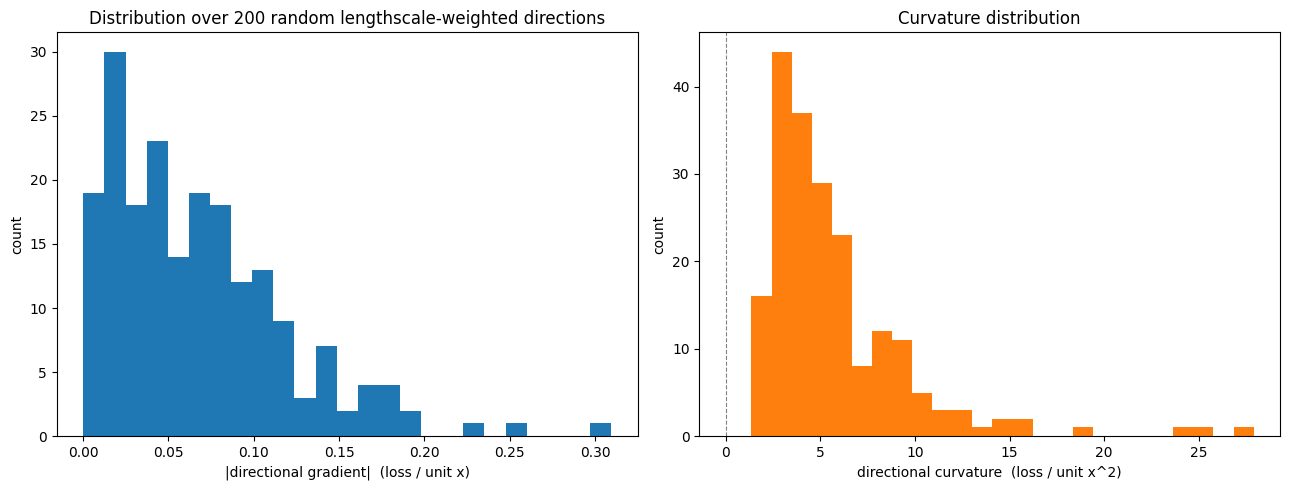

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(results_df["gradient"].abs(), bins=25, color="C0")
axes[0].set_xlabel("|directional gradient|  (loss / unit x)")
axes[0].set_ylabel("count")
axes[0].set_title(f"Distribution over {len(results_df)} random lengthscale-weighted directions")

axes[1].hist(results_df["curvature"], bins=25, color="C1")
axes[1].axvline(0.0, color="gray", linewidth=0.8, linestyle="--")
axes[1].set_xlabel("directional curvature  (loss / unit x^2)")
axes[1].set_ylabel("count")
axes[1].set_title("Curvature distribution")

fig.tight_layout()
plt.show()


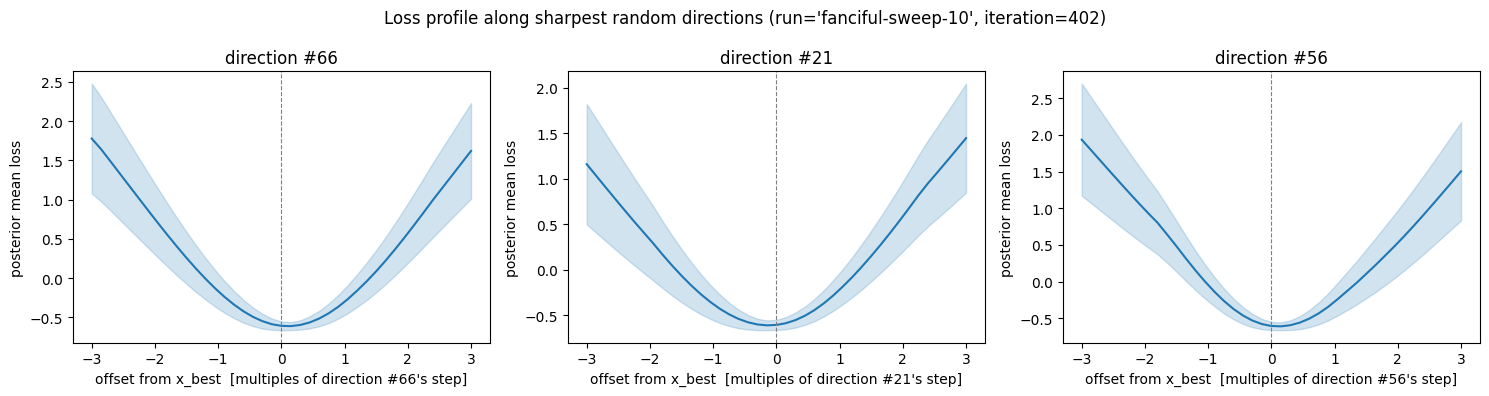

In [31]:
# 1D profiles along the sharpest random directions found above: sweep +/- a
# few step-lengths along that specific combined direction and plot the GP
# posterior mean (+/- 1 std) to see directly whether the optimum is a sharp
# spike or a broad basin along that direction.
top = results_df.reindex(results_df["gradient"].abs().sort_values(ascending=False).index)
top = top.head(N_PROFILE_DIRECTIONS)

t_grid = np.linspace(-3.0, 3.0, 41)
fig, axes = plt.subplots(1, len(top), figsize=(5 * len(top), 4), squeeze=False)
axes = axes[0]

for ax, (_, row) in zip(axes, top.iterrows()):
    d_unit = directions[int(row["direction"])]
    step = row["step_norm"]
    xs = x_best[None, :] + t_grid[:, None] * step * d_unit[None, :]
    xs = np.clip(xs, lo, hi)
    mu, std = posterior_mean_std(model, xs)

    ax.plot(t_grid, mu, color="C0")
    ax.fill_between(t_grid, mu - std, mu + std, color="C0", alpha=0.2)
    ax.axvline(0.0, color="gray", linewidth=0.8, linestyle="--")
    ax.set_xlabel(f"offset from x_best  [multiples of direction #{int(row['direction'])}'s step]")
    ax.set_ylabel("posterior mean loss")
    ax.set_title(f"direction #{int(row['direction'])}")

fig.suptitle(f"Loss profile along sharpest random directions (run='{best_run.name}', iteration={i_star})")
fig.tight_layout()
plt.show()


## Step 6 — is it a sharp spike?

`delta_over_std` above is `(0.5*(mu_plus + mu_minus) - mu_best) / std(Y_train)`:
the average rise in loss after stepping one lengthscale-weighted random
direction's worth of distance away from the best point, expressed in units of
the overall loss variability seen in training. As a rule of thumb:

- **`delta_over_std` small (<< 1) across (nearly) all sampled directions** ->
  the minimum sits in a broad, well-conditioned basin; nearby points in any
  combination of DOFs have similar loss.
- **`delta_over_std` large (>= 1) for a meaningful fraction of directions** ->
  the loss rises sharply within a small fraction of the GP's own correlation
  length along many random combinations of DOFs -- i.e. a narrow spike that a
  slightly different `x` would likely miss (fragile optimum, worth extra real
  VMEC/tracing evals nearby to confirm it isn't a surrogate artifact).

In [32]:
summary = results_df[["direction", "step_norm", "gradient", "curvature", "delta_over_std"]].copy()
summary["abs_delta_over_std"] = summary["delta_over_std"].abs()
summary = summary.sort_values("abs_delta_over_std", ascending=False).drop(columns="abs_delta_over_std")

sharp_dirs = summary[summary["delta_over_std"].abs() >= 1.0]
frac_sharp = len(sharp_dirs) / len(summary)
print(f"Run '{best_run.name}', iteration {i_star}, best loss {mu0:.6e}\n")
print(f"{len(sharp_dirs)}/{len(summary)} random directions ({frac_sharp:.0%}) show delta_over_std >= 1.\n")
if sharp_dirs.empty:
    print("No random direction shows delta_over_std >= 1: the optimum looks like a broad "
          "basin, not a sharp spike, under the GP surrogate.")
else:
    print("Sharpest directions:")
    print(sharp_dirs.head(10).to_string(index=False))

summary.head(20)


Run 'fanciful-sweep-10', iteration 402, best loss -6.065807e-01

0/200 random directions (0%) show delta_over_std >= 1.

No random direction shows delta_over_std >= 1: the optimum looks like a broad basin, not a sharp spike, under the GP surrogate.


,direction,step_norm,gradient,curvature,delta_over_std
64,70,0.409333,-0.082994,8.917251,0.415185
163,10,0.304360,-0.019738,15.670491,0.403382
153,131,0.533837,-0.023393,5.077322,0.402077
100,111,0.557109,0.057132,4.493019,0.387504
102,98,0.468407,-0.056450,6.145703,0.374693
55,195,0.599686,-0.089057,3.532969,0.353057
156,3,0.551602,0.022577,4.049887,0.342415
135,114,0.290452,-0.034584,14.595171,0.342148
125,181,0.500746,-0.041246,4.906808,0.341894
146,175,0.516886,0.026768,4.588548,0.340661
